In [1]:
import sys
from pathlib import Path
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json

from Models.AutoEncoder import AutoEncoder
from Utils.DataUtils import build_ae_dataloaders
from Utils.FeatureUtils import extract_features
from lightgbm import LGBMClassifier
import lightgbm as lgb
from catboost import CatBoostClassifier
from xgboost import XGBClassifier

from Models.FraudModel import FraudMLP
from Models.EnsembleModel import (
    TorchBinaryProbWrapper,
    WeightedFraudEnsemble,
    StackingFraudMLP,
    FeatureRichStackingFraudMLP,
    StackedFraudEnsemble,
    CatBoostAEWrapper,
    XGBoostAEWrapper,
    collect_member_probs,
    collect_weighted_ensemble_probs,
    collect_stacked_ensemble_probs,
    collect_labels,
)

In [2]:
# Config
BATCH_SIZE = 256
LR = 1e-3
EPOCHS = 30
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
# AE training, train only non-fraud
train_loader_ae, val_loader, test_loader, input_dim = build_ae_dataloaders(
    batch_size=BATCH_SIZE,
    mode="ae",
    train_only_nonfraud=True,
    return_labels=True
)

# Train fraud + non-fraud
train_loader_full, _, _, _ = build_ae_dataloaders(
    batch_size=BATCH_SIZE,
    mode="ae",
    train_only_nonfraud=False,
    return_labels=True
)

print("Input dim:", input_dim)

[INFO] Project root: C:\DeepLearning\DL_project
[INFO] Data dir: C:\DeepLearning\DL_project\data
[INFO] Loading train data from: C:\DeepLearning\DL_project\data\train_transaction.csv
[INFO] Loading test data from: C:\DeepLearning\DL_project\data\test_transaction.csv
[INFO] Train shape: (590540, 394)
[INFO] Test shape: (506691, 393)


C:\DeepLearning\DL_project\Utils\Preprocess.py:78: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[col + "_missing"] = df[col].isna().astype(int)
C:\DeepLearning\DL_project\Utils\Preprocess.py:78: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[col + "_missing"] = df[col].isna().astype(int)
C:\DeepLearning\DL_project\Utils\Preprocess.py:78: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using

[INFO] Train: (455902, 776)
[INFO] Val: (59054, 776)
[INFO] Test: (59054, 776)
[INFO] Project root: C:\DeepLearning\DL_project
[INFO] Data dir: C:\DeepLearning\DL_project\data
[INFO] Loading train data from: C:\DeepLearning\DL_project\data\train_transaction.csv
[INFO] Loading test data from: C:\DeepLearning\DL_project\data\test_transaction.csv
[INFO] Train shape: (590540, 394)
[INFO] Test shape: (506691, 393)


C:\DeepLearning\DL_project\Utils\Preprocess.py:78: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[col + "_missing"] = df[col].isna().astype(int)
C:\DeepLearning\DL_project\Utils\Preprocess.py:78: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[col + "_missing"] = df[col].isna().astype(int)
C:\DeepLearning\DL_project\Utils\Preprocess.py:78: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using

[INFO] Train: (472432, 776)
[INFO] Val: (59054, 776)
[INFO] Test: (59054, 776)
Input dim: 776


In [4]:
# Load AutoEncoder checkpoint
ae_ckpt = torch.load("checkpoints/autoencoder.pt", map_location=DEVICE)

ae = AutoEncoder(
    input_dim=ae_ckpt["input_dim"],
    latent_dim=ae_ckpt["latent_dim"],
    hidden_dims=ae_ckpt["hidden_dims"],
).to(DEVICE)

ae.load_state_dict(ae_ckpt["model_state_dict"])
ae.eval()

AutoEncoder(
  (encoder): Sequential(
    (0): Linear(in_features=776, out_features=128, bias=True)
    (1): GELU(approximate='none')
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): GELU(approximate='none')
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): GELU(approximate='none')
    (6): Linear(in_features=32, out_features=256, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=256, out_features=32, bias=True)
    (1): GELU(approximate='none')
    (2): Linear(in_features=32, out_features=64, bias=True)
    (3): GELU(approximate='none')
    (4): Linear(in_features=64, out_features=128, bias=True)
    (5): GELU(approximate='none')
    (6): Linear(in_features=128, out_features=776, bias=True)
  )
)

In [5]:
# Features for Tree Models
X_test, y_test = extract_features(ae, test_loader, DEVICE)
y_test = np.array(y_test)

# LightGBM
lgb_model = lgb.Booster(model_file="checkpoints/lgbm_model.txt")
y_proba_lgb = lgb_model.predict(X_test)

# CatBoost
cb_model = CatBoostClassifier()
cb_model.load_model("checkpoints/best_catboost.cbm")
y_proba_cb = cb_model.predict_proba(X_test)[:, 1]

# XGBoost
xgb_model = XGBClassifier()
xgb_model.load_model("checkpoints/best_xgboost.json")
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

# Ensemble
# construct baseV6
model_base_v6 = FraudMLP(
    input_dim=input_dim,
    hidden_dims=[1024, 512, 256, 128, 64],
    gated=True,
    dropout=0.1,
    encoder=None,
    freeze_encoder=False,
).to(DEVICE)

model_base_v6_ckpt = torch.load("checkpoints/GatedMLP_V6/best.pt", map_location=DEVICE)
if "model_state_dict" in model_base_v6_ckpt:
    model_base_v6.load_state_dict(model_base_v6_ckpt["model_state_dict"])
else:
    model_base_v6.load_state_dict(model_base_v6_ckpt)

model_base_v6.eval()

# construct model ae16
autoencoder16  = AutoEncoder(
    input_dim=input_dim,
    latent_dim=16,
    hidden_dims=[128, 64],
    noise_std=0.01,
).to(DEVICE)

ae_ckpt16 = torch.load("checkpoints/ae_best_L16.pt", map_location=DEVICE)
if "model_state_dict" in ae_ckpt16:
    autoencoder16.load_state_dict(ae_ckpt16["model_state_dict"])
else:
    autoencoder16.load_state_dict(ae_ckpt16)
autoencoder16.eval()

model_ae16 = FraudMLP(
    input_dim=input_dim,
    hidden_dims=[1024, 512, 256, 128, 64],
    gated=True,
    dropout=0.1,
    use_norm=True,
    encoder=autoencoder16,
    freeze_encoder=True,
).to(DEVICE)

ckpt_model_ae16 = torch.load("checkpoints/GatedMLP_AE16_V4/best.pt", map_location=DEVICE)
if "model_state_dict" in ckpt_model_ae16:
    model_ae16.load_state_dict(ckpt_model_ae16["model_state_dict"])
else:
    model_ae16.load_state_dict(ckpt_model_ae16)

model_ae16.eval()

# construct model ae256
autoencoder256 = AutoEncoder(
    input_dim=input_dim,
    latent_dim=256,
    hidden_dims=[128, 64, 32],
    noise_std=0.01,
).to(DEVICE)

ae_ckpt256 = torch.load("checkpoints/autoencoder.pt", map_location=DEVICE)
ae_state_dict256 = ae_ckpt256["model_state_dict"] if "model_state_dict" in ae_ckpt256 else ae_ckpt256
autoencoder256.load_state_dict(ae_state_dict256)
autoencoder256.eval()

model_ae256 = FraudMLP(
    input_dim=input_dim,
    hidden_dims=[1024, 512, 256, 128, 64],
    gated=True,
    dropout=0.1,
    encoder=autoencoder256,
    freeze_encoder=True,
).to(DEVICE)

ckpt_model_ae256 = torch.load("checkpoints/GatedMLP_AE256_V1/best.pt", map_location=DEVICE)
state_dict_model_ae256 = ckpt_model_ae256["model_state_dict"] if "model_state_dict" in ckpt_model_ae256 else ckpt_model_ae256

model_ae256.load_state_dict(state_dict_model_ae256)
model_ae256.eval()

# construct catboost model
cat_model = CatBoostClassifier()
cat_model.load_model("checkpoints/best_catboost.cbm")

cat_member = CatBoostAEWrapper(
    cat_model=cat_model,
    autoencoder=autoencoder256
)

# construct xgboost model
with open("checkpoints/best_xgboost_params.json", "r") as f:
    xgb_meta = json.load(f)

xgb_model = XGBClassifier()
xgb_model.load_model("checkpoints/best_xgboost.json")

xgb_member = XGBoostAEWrapper(
    xgb_model=xgb_model,
    autoencoder=autoencoder256,
)

members = [
    TorchBinaryProbWrapper(model_base_v6),
    TorchBinaryProbWrapper(model_ae16),
    TorchBinaryProbWrapper(model_ae256),
    cat_member,
    xgb_member
]

ckpt = torch.load(
    "checkpoints/StackedEnsemble_FULL_CAT_XGB_TREE_32_16_8_TRAINVAL.pt",
    map_location="cpu"
)

stacker_cfg = ckpt["stacker_config"]

stacker = StackingFraudMLP(
    input_dim=stacker_cfg["input_dim"],
    hidden_dims=stacker_cfg["hidden_dims"],
    dropout=stacker_cfg["dropout"],
    use_norm=stacker_cfg["use_norm"],
).to(DEVICE)

stacker.load_state_dict(ckpt["stacker_state_dict"])

stacked_ensemble = StackedFraudEnsemble(
    members=members,
    stacker=stacker
).to(DEVICE)

stacked_ensemble.eval()

y_proba_stack = collect_stacked_ensemble_probs(
    ensemble=stacked_ensemble,
    loader=test_loader,
    device=DEVICE
).cpu().numpy()

# AutoEncoder

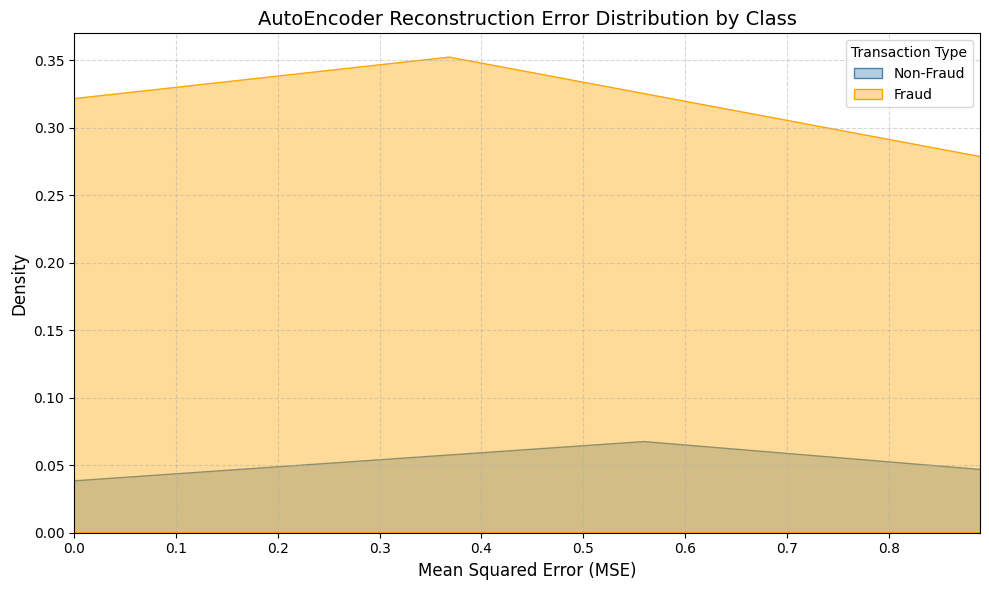

In [6]:
# Reconstruction Error Distribution - For AutoEncoder
def get_recon_errors(loader):
    ae.eval()
    errors, labels = [], []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(DEVICE)
            x_hat, _ = ae(x)

            err = torch.mean((x - x_hat) ** 2, dim=1)

            errors.extend(err.cpu().numpy())
            labels.extend(y.numpy())

    return np.array(errors), np.array(labels)

errors, labels = get_recon_errors(test_loader)

plt.figure(figsize=(10, 6))
sns.kdeplot(errors[labels == 0], label="Non-Fraud", fill=True, color='steelblue', common_norm=False, alpha=0.4)
sns.kdeplot(errors[labels == 1], label="Fraud", fill=True, color='orange', common_norm=False, alpha=0.4)
plt.xlim(0, np.percentile(errors, 95) * 3)
plt.title("AutoEncoder Reconstruction Error Distribution by Class", fontsize=14)
plt.xlabel("Mean Squared Error (MSE)", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.legend(title="Transaction Type")
plt.grid(axis='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("images/ae_reconstruction_error.png", dpi=300, bbox_inches="tight")
plt.show()

# Light GBM

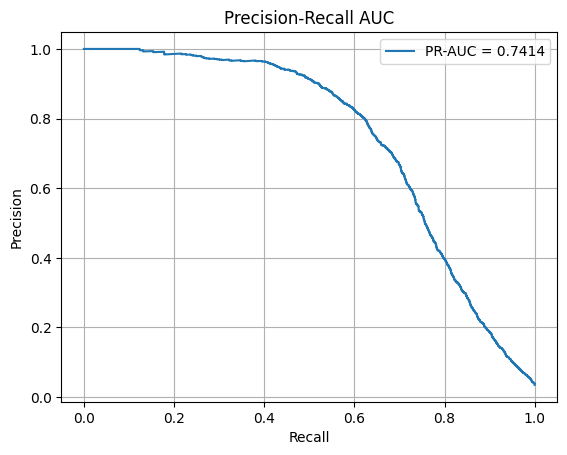

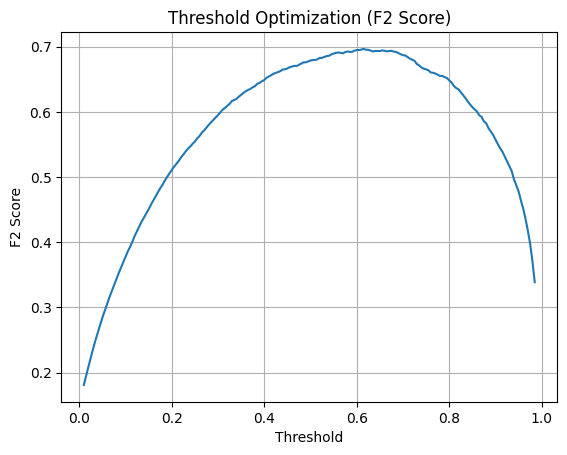

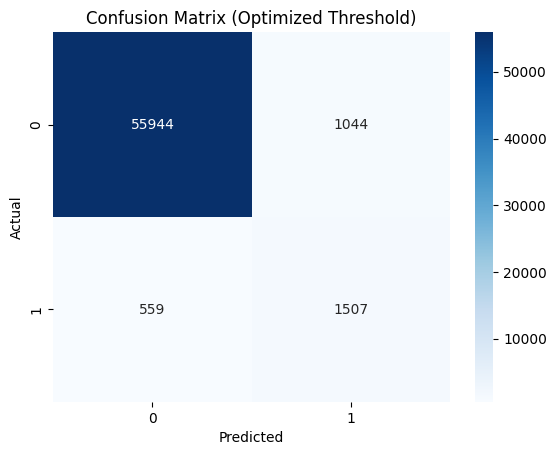

In [7]:
# Precision Recall AUC
from sklearn.metrics import precision_recall_curve, auc

precision, recall, _ = precision_recall_curve(y_test, y_proba_lgb)
pr_auc = auc(recall, precision)

plt.figure()
plt.plot(recall, precision, label=f"PR-AUC = {pr_auc:.4f}")
plt.title("Precision-Recall AUC")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.grid()
plt.savefig("images/prauc_lightgbm.png", dpi=300, bbox_inches="tight")
plt.show()

# Threshold vs F2 Curve
from sklearn.metrics import fbeta_score

thresholds = np.arange(0.01, 0.99, 0.005)
f2_scores = []

for t in thresholds:
    preds = (y_proba_lgb >= t).astype(int)
    f2_scores.append(fbeta_score(y_test, preds, beta=2))

plt.figure()
plt.plot(thresholds, f2_scores)
plt.title("Threshold Optimization (F2 Score)")
plt.xlabel("Threshold")
plt.ylabel("F2 Score")
plt.grid()
plt.savefig("images/best_threshold_lightgbm.png", dpi=300, bbox_inches="tight")
plt.show()

# Confusion Matrix (Best Threshold)
from sklearn.metrics import confusion_matrix

best_thresh = 0.615
y_pred = (y_proba_lgb >= best_thresh).astype(int)

cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix (Optimized Threshold)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("images/confusion_matrix_lightgbm.png", dpi=300, bbox_inches="tight")
plt.show()

# CatBoost

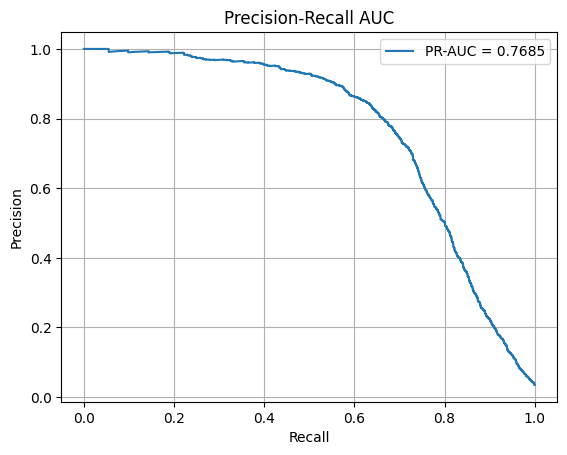

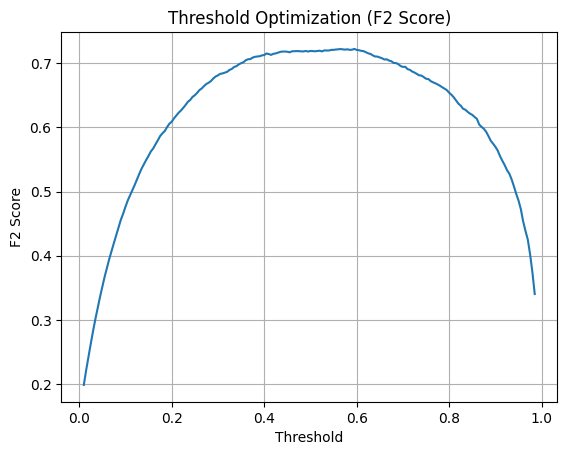

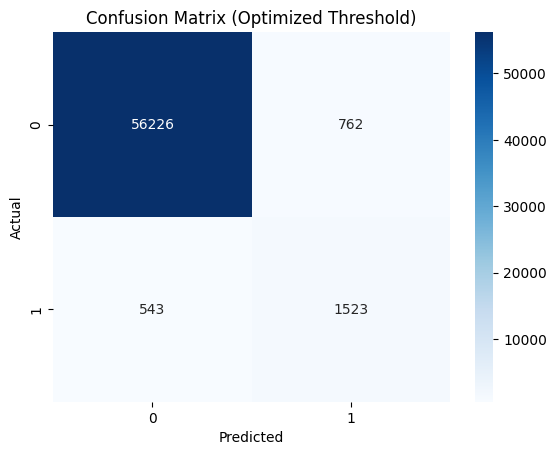

In [8]:
# Precision Recall AUC
from sklearn.metrics import precision_recall_curve, auc

precision, recall, _ = precision_recall_curve(y_test, y_proba_cb)
pr_auc = auc(recall, precision)

plt.figure()
plt.plot(recall, precision, label=f"PR-AUC = {pr_auc:.4f}")
plt.title("Precision-Recall AUC")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.grid()
plt.savefig("images/prauc_catboost.png", dpi=300, bbox_inches="tight")
plt.show()

# Threshold vs F2 Curve
from sklearn.metrics import fbeta_score

thresholds = np.arange(0.01, 0.99, 0.005)
f2_scores = []

for t in thresholds:
    preds = (y_proba_cb >= t).astype(int)
    f2_scores.append(fbeta_score(y_test, preds, beta=2))

plt.figure()
plt.plot(thresholds, f2_scores)
plt.title("Threshold Optimization (F2 Score)")
plt.xlabel("Threshold")
plt.ylabel("F2 Score")
plt.grid()
plt.savefig("images/best_threshold_catboost.png", dpi=300, bbox_inches="tight")
plt.show()

# Confusion Matrix (Best Threshold)
from sklearn.metrics import confusion_matrix

best_thresh = 0.57
y_pred = (y_proba_cb >= best_thresh).astype(int)

cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix (Optimized Threshold)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("images/confusion_matrix_catboost.png", dpi=300, bbox_inches="tight")
plt.show()

# XGBoost

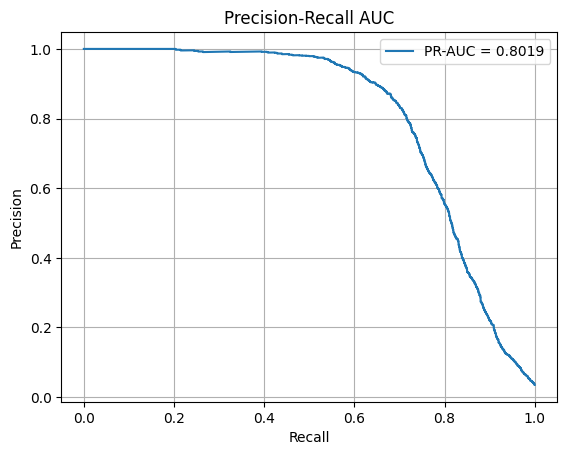

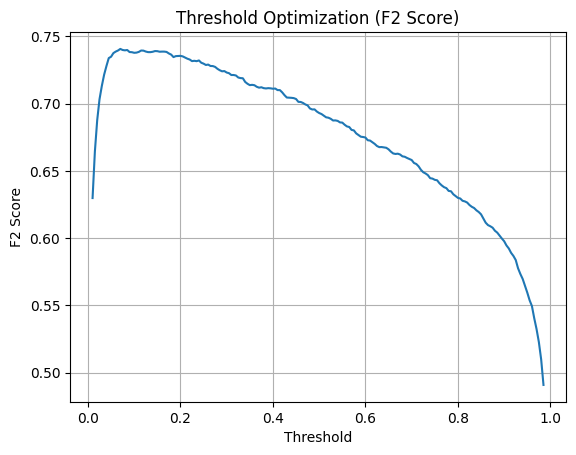

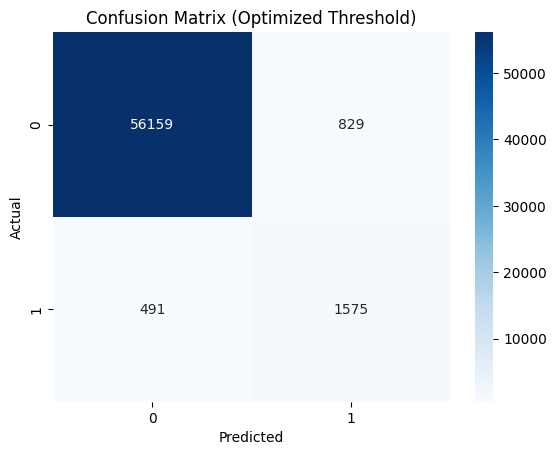

In [9]:
# Precision Recall AUC
from sklearn.metrics import precision_recall_curve, auc

precision, recall, _ = precision_recall_curve(y_test, y_proba_xgb)
pr_auc = auc(recall, precision)

plt.figure()
plt.plot(recall, precision, label=f"PR-AUC = {pr_auc:.4f}")
plt.title("Precision-Recall AUC")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.grid()
plt.savefig("images/prauc_xgboost.png", dpi=300, bbox_inches="tight")
plt.show()

# Threshold vs F2 Curve
from sklearn.metrics import fbeta_score

thresholds = np.arange(0.01, 0.99, 0.005)
f2_scores = []

for t in thresholds:
    preds = (y_proba_xgb >= t).astype(int)
    f2_scores.append(fbeta_score(y_test, preds, beta=2))

plt.figure()
plt.plot(thresholds, f2_scores)
plt.title("Threshold Optimization (F2 Score)")
plt.xlabel("Threshold")
plt.ylabel("F2 Score")
plt.grid()
plt.savefig("images/best_threshold_xgboost.png", dpi=300, bbox_inches="tight")
plt.show()

# Confusion Matrix (Best Threshold)
from sklearn.metrics import confusion_matrix

best_thresh = 0.095
y_pred = (y_proba_xgb >= best_thresh).astype(int)

cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix (Optimized Threshold)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("images/confusion_matrix_xgboost.png", dpi=300, bbox_inches="tight")
plt.show()

# Ensemble

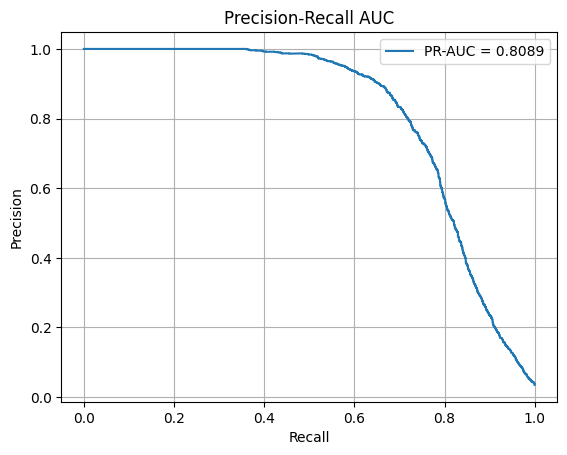

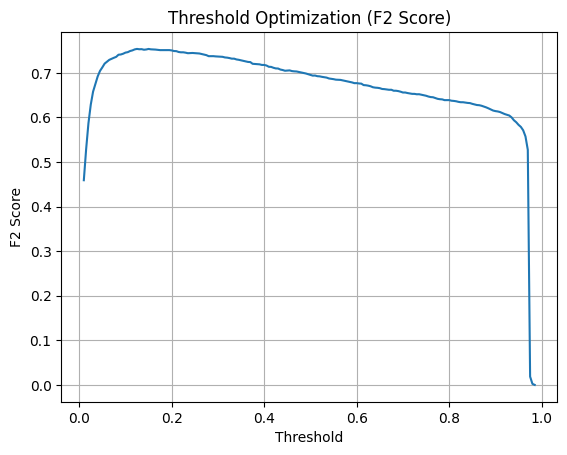

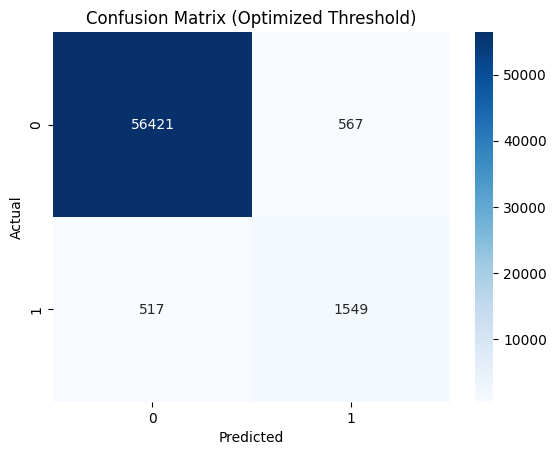

In [10]:
# Precision Recall AUC
from sklearn.metrics import precision_recall_curve, auc

precision, recall, _ = precision_recall_curve(y_test, y_proba_stack)
pr_auc = auc(recall, precision)

plt.figure()
plt.plot(recall, precision, label=f"PR-AUC = {pr_auc:.4f}")
plt.title("Precision-Recall AUC")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.grid()
plt.savefig("images/prauc_ensemble.png", dpi=300, bbox_inches="tight")
plt.show()

# Threshold vs F2 Curve
from sklearn.metrics import fbeta_score

thresholds = np.arange(0.01, 0.99, 0.005)
f2_scores = []

for t in thresholds:
    preds = (y_proba_stack >= t).astype(int)
    f2_scores.append(fbeta_score(y_test, preds, beta=2))

plt.figure()
plt.plot(thresholds, f2_scores)
plt.title("Threshold Optimization (F2 Score)")
plt.xlabel("Threshold")
plt.ylabel("F2 Score")
plt.grid()
plt.savefig("images/best_threshold_ensemble.png", dpi=300, bbox_inches="tight")
plt.show()

# Confusion Matrix (Best Threshold)
from sklearn.metrics import confusion_matrix

best_thresh = 0.21921023726463318
y_pred = (y_proba_stack >= best_thresh).astype(int)

cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix (Optimized Threshold)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("images/confusion_matrix_ensemble.png", dpi=300, bbox_inches="tight")
plt.show()